# Phase 1 — `min_burst_len` Sweep

Sweeps `min_burst_len` ∈ [3, 10, 20, 50] to find the value that:
- Keeps cyclostationary invocation rate **high** on signal segments
- Suppresses invocation on **noise** segments

Uses the updated SCF-based `cyclo_detector`. All outputs saved to `results/review_1/`.

In [ ]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from glob import glob
from pathlib import Path
from dotenv import load_dotenv
from sklearn.metrics import roc_curve, auc

# ensure src/ is on path when running from notebook dir
ROOT = Path().resolve().parents[2]
sys.path.insert(0, str(ROOT / "src"))

from rfml_uav.drone_rf.consts import BUI, FS_HZ
from rfml_uav.drone_rf.utils import get_segment_count, get_binary_label
from rfml_uav.signal_detection.methods import energy_detector, cyclo_detector
from rfml_uav.signal_detection.cascade import aggregate_bursts, cyclo_on_burst

load_dotenv()
CHUNKED_PATH = Path(os.getenv("DATA_PATH")) / "chunked"
OUT = ROOT / "results" / "review_1"
OUT.mkdir(parents=True, exist_ok=True)

np.random.seed(42)

SWEEP_VALS = [3, 10, 20, 50]
PFA_TARGET = 0.05
BG_BUI     = "00000"

print(f"ROOT          : {ROOT}")
print(f"CHUNKED_PATH  : {CHUNKED_PATH}")
print(f"OUT           : {OUT}")

ROOT          : /home/ivan/work/ml/rfml-uav/notebooks
CHUNKED_PATH  : /home/ivan/work/ml/rfml-uav/data/drone-rf/chunked
OUT           : /home/ivan/work/ml/rfml-uav/notebooks/results/review_1


## Energy threshold (background)

In [2]:
bg_scores = []
for seg in range(get_segment_count(BG_BUI)):
    for fp in sorted(glob(str(CHUNKED_PATH / f"{BG_BUI}*_{seg}.npz"))):
        chunks = np.load(fp)["arr_0"]
        bg_scores.extend(energy_detector(x) for x in chunks)

thr_energy = np.percentile(bg_scores, 100 * (1 - PFA_TARGET))
print(f"thr_energy = {thr_energy:.6f}  (Pfa = {PFA_TARGET})")

thr_energy = 14.769512  (Pfa = 0.05)


## Helpers

In [3]:
def run_cascade_segment(files, min_burst_len):
    """Return (cascade_score, cyclo_invoked, burst_lengths)."""
    all_cascade_scores = []
    cyclo_invoked_flag = False
    all_burst_lengths  = []

    for fp in files:
        chunks    = np.load(fp)["arr_0"]
        e_scores  = [energy_detector(x) for x in chunks]
        decisions = [s >= thr_energy for s in e_scores]
        bursts    = aggregate_bursts(decisions, min_len=min_burst_len)

        if bursts:
            cyclo_invoked_flag = True
            all_burst_lengths.extend(b1 - b0 for b0, b1 in bursts)
            c_scores = [cyclo_on_burst(chunks[b0:b1], FS_HZ) for b0, b1 in bursts]
            all_cascade_scores.append(max(c_scores))

    final = max(all_cascade_scores) if all_cascade_scores else 0.0
    return final, cyclo_invoked_flag, all_burst_lengths

## Sweep

In [4]:
from tqdm import tqdm

records = []

for min_burst_len in SWEEP_VALS:
    print(f"\n── min_burst_len = {min_burst_len} ──")
    seg_scores, seg_labels = [], []
    inv_signal, tot_signal = 0, 0
    inv_noise,  tot_noise  = 0, 0
    all_burst_lengths      = []

    for bui in tqdm(BUI, desc=f"  BUI sweep (mbl={min_burst_len})"):
        label = get_binary_label(bui)
        for seg in range(get_segment_count(bui)):
            files = sorted(glob(str(CHUNKED_PATH / f"{bui}*_{seg}.npz")))
            if not files:
                continue
            score, invoked, blens = run_cascade_segment(files, min_burst_len)
            seg_scores.append(score)
            seg_labels.append(label)
            all_burst_lengths.extend(blens)
            if label == 1:
                tot_signal += 1
                inv_signal += int(invoked)
            else:
                tot_noise += 1
                inv_noise  += int(invoked)

    seg_scores = np.array(seg_scores)
    seg_labels = np.array(seg_labels)

    fpr, tpr, _ = roc_curve(seg_labels, seg_scores)
    roc_auc     = auc(fpr, tpr)
    ok = np.where(fpr <= PFA_TARGET)[0]
    i  = ok[np.argmax(tpr[ok])] if len(ok) else np.argmin(fpr)

    rate_signal = inv_signal / tot_signal if tot_signal else 0.0
    rate_noise  = inv_noise  / tot_noise  if tot_noise  else 0.0
    rate_total  = (inv_signal + inv_noise) / (tot_signal + tot_noise)

    print(f"  AUC={roc_auc:.3f}  Pd={float(tpr[i]):.3f}  Pfa={float(fpr[i]):.3f}")
    print(f"  invocation — signal: {rate_signal*100:.1f}%  "
          f"noise: {rate_noise*100:.1f}%  total: {rate_total*100:.1f}%")

    records.append({
        "min_burst_len":   min_burst_len,
        "AUC":             roc_auc,
        "Pd":              float(tpr[i]),
        "Pfa":             float(fpr[i]),
        "inv_signal":      rate_signal,
        "inv_noise":       rate_noise,
        "inv_total":       rate_total,
        "tot_signal_segs": tot_signal,
        "tot_noise_segs":  tot_noise,
        "mean_burst_len":  float(np.mean(all_burst_lengths)) if all_burst_lengths else 0.0,
        "_fpr": fpr,
        "_tpr": tpr,
    })


── min_burst_len = 3 ──


  BUI sweep (mbl=3): 100%|██████████| 10/10 [03:53<00:00, 23.36s/it]


  AUC=1.000  Pd=1.000  Pfa=0.000
  invocation — signal: 100.0%  noise: 100.0%  total: 100.0%

── min_burst_len = 10 ──


  BUI sweep (mbl=10): 100%|██████████| 10/10 [03:50<00:00, 23.03s/it]


  AUC=1.000  Pd=1.000  Pfa=0.000
  invocation — signal: 100.0%  noise: 100.0%  total: 100.0%

── min_burst_len = 20 ──


  BUI sweep (mbl=20): 100%|██████████| 10/10 [03:48<00:00, 22.85s/it]


  AUC=1.000  Pd=1.000  Pfa=0.000
  invocation — signal: 100.0%  noise: 100.0%  total: 100.0%

── min_burst_len = 50 ──


  BUI sweep (mbl=50): 100%|██████████| 10/10 [03:42<00:00, 22.25s/it]

  AUC=1.000  Pd=1.000  Pfa=0.000
  invocation — signal: 100.0%  noise: 2.4%  total: 82.4%


## Results table

In [5]:
df = pd.DataFrame([{k: v for k, v in r.items() if not k.startswith("_")}
                   for r in records])
csv_path = OUT / "burst_sweep_results.csv"
df.to_csv(csv_path, index=False)

display(df.style
    .format({
        "AUC": "{:.3f}", "Pd": "{:.3f}", "Pfa": "{:.3f}",
        "inv_signal": "{:.1%}", "inv_noise": "{:.1%}", "inv_total": "{:.1%}",
        "mean_burst_len": "{:.1f}",
    })
    .set_caption("Cascade sweep: detection and selectivity by min_burst_len")
)
print(f"Saved: {csv_path}")

,min_burst_len,AUC,Pd,Pfa,inv_signal,inv_noise,inv_total,tot_signal_segs,tot_noise_segs,mean_burst_len
0,3,1.000,1.000,0.000,100.0%,100.0%,100.0%,186,41,119.3
1,10,1.000,1.000,0.000,100.0%,100.0%,100.0%,186,41,182.0
2,20,1.000,1.000,0.000,100.0%,100.0%,100.0%,186,41,212.7
3,50,1.000,1.000,0.000,100.0%,2.4%,82.4%,186,41,303.2


Saved: /home/ivan/work/ml/rfml-uav/results/review_1/burst_sweep_results.csv


## Invocation rate by label

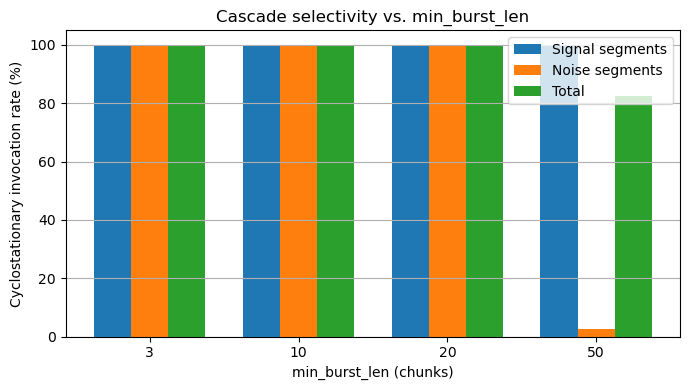

Saved: /home/ivan/work/ml/rfml-uav/results/review_1/burst_sweep_invocation.png


In [6]:
fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(len(SWEEP_VALS))
w = 0.25
ax.bar(x - w, df["inv_signal"] * 100, w, label="Signal segments")
ax.bar(x,     df["inv_noise"]  * 100, w, label="Noise segments")
ax.bar(x + w, df["inv_total"]  * 100, w, label="Total")
ax.set_xticks(x)
ax.set_xticklabels([str(v) for v in SWEEP_VALS])
ax.set_xlabel("min_burst_len (chunks)")
ax.set_ylabel("Cyclostationary invocation rate (%)")
ax.set_title("Cascade selectivity vs. min_burst_len")
ax.legend()
ax.grid(axis="y")
fig.tight_layout()
fig.savefig(OUT / "burst_sweep_invocation.png", dpi=150)
plt.show()
print(f"Saved: {OUT / 'burst_sweep_invocation.png'}")

## ROC curves

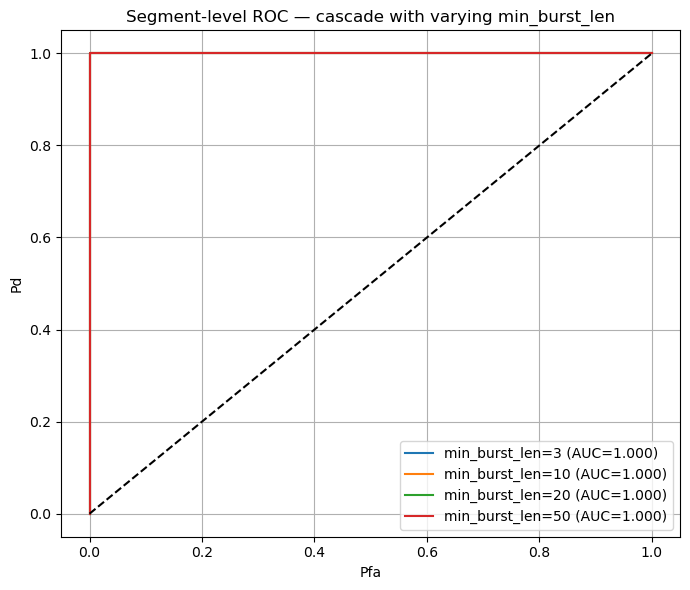

Saved: /home/ivan/work/ml/rfml-uav/results/review_1/burst_sweep_roc.png


In [7]:
fig, ax = plt.subplots(figsize=(7, 6))
for r in records:
    ax.plot(r["_fpr"], r["_tpr"],
            label=f"min_burst_len={r['min_burst_len']} (AUC={r['AUC']:.3f})")
ax.plot([0, 1], [0, 1], "k--")
ax.set_xlabel("Pfa")
ax.set_ylabel("Pd")
ax.set_title("Segment-level ROC — cascade with varying min_burst_len")
ax.legend()
ax.grid(True)
fig.tight_layout()
fig.savefig(OUT / "burst_sweep_roc.png", dpi=150)
plt.show()
print(f"Saved: {OUT / 'burst_sweep_roc.png'}")